In [ ]:
import pandas as pd


df = pd.read_csv("/content/cybersecurity_intrusion_data.csv")
print(df.head())

  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected  
0         Edge                    0                1  
1      Firefox                    0 

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [ ]:
df_cleaned = df.drop(columns=['session_id'])
df.drop(columns=['session_id'], inplace=True)



In [ ]:
df_encoded = pd.get_dummies(df, columns=['protocol_type', 'encryption_used', 'browser_type'], drop_first=True)
print(df_encoded)

      network_packet_size  login_attempts  session_duration  \
0                     599               4        492.983263   
1                     472               3       1557.996461   
2                     629               3         75.044262   
3                     804               4        601.248835   
4                     453               5        532.540888   
...                   ...             ...               ...   
9532                  194               3        226.049889   
9533                  380               3        182.848475   
9534                  664               5         35.170248   
9535                  406               4         86.664703   
9536                  340               6         86.876744   

      ip_reputation_score  failed_logins  unusual_time_access  \
0                0.606818              1                    0   
1                0.301569              0                    0   
2                0.739164              2        

In [ ]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=['attack_detected'])
y = df_encoded['attack_detected']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])



Training set size: 7629
Testing set size: 1908


In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree with stopping conditions
clf_pruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=5,
)

# Train the Decision Tree
clf_pruned.fit(X_train, y_train)

# Display the depth of the trained tree
print(f"Tree Depth: {clf_pruned.get_depth()}")
print(f"Number of Leaves: {clf_pruned.get_n_leaves()}")


Tree Depth: 5
Number of Leaves: 7


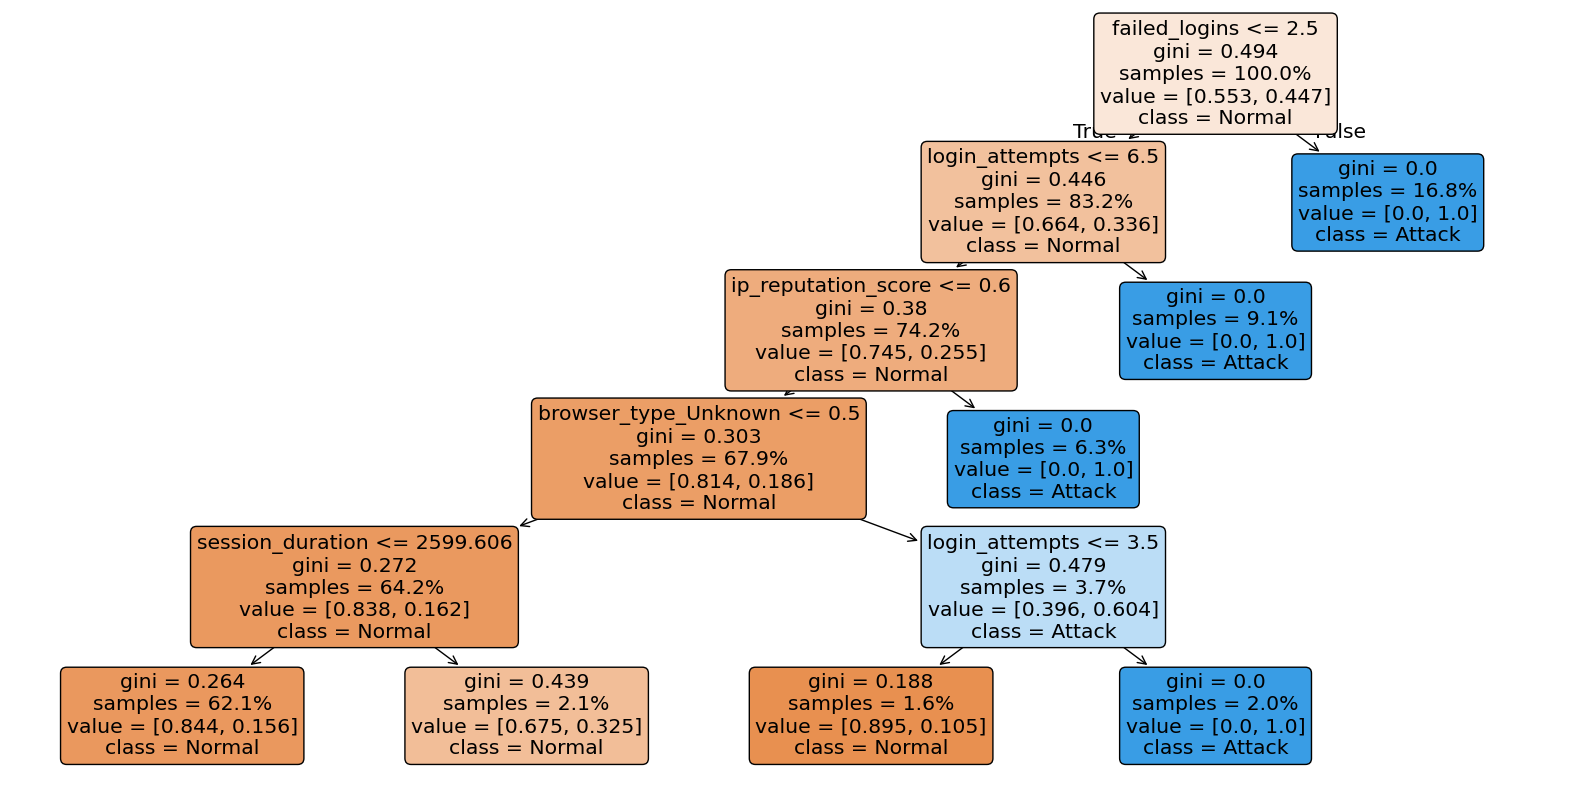

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(clf_pruned, filled=True, feature_names=X.columns, class_names=['Normal', 'Attack'], rounded=True, proportion=True)
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score
y_pred = clf_pruned.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8841719077568134


In [ ]:
# now we have to apply different parameter to get 5 different varient of our decision tree
# Increasing max_features for Randomness
clf_variant_1 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    max_features='sqrt',   #  (square root of total features)
    random_state=42
)
clf_variant_1.fit(X_train, y_train)
y_pred = clf_variant_1.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy of the Decision Tree (Variant 1):", acc)



Accuracy of the Decision Tree (Variant 1): 0.8034591194968553


In [ ]:
#  Enabling Pruning with ccp_alpha (Cost Complexity Pruning)
clf_variant_2 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=None,
    ccp_alpha=0.01,        # Enable pruning with small cost-complexity value
    random_state=42
)
clf_variant_2.fit(X_train, y_train)
y_pred = clf_variant_1.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy of the Decision Tree (Variant 2):", acc)


Accuracy of the Decision Tree (Variant 2): 0.8034591194968553


In [ ]:
# Using class_weight to Handle Imbalanced Classes
clf_variant_3 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    class_weight='balanced',  # Assign weights inversely proportional to class frequencies
    random_state=42
)
clf_variant_3.fit(X_train, y_train)
y_pred = clf_variant_3.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy of the Decision Tree (Variant 3):", acc)

Accuracy of the Decision Tree (Variant 3): 0.8773584905660378


In [ ]:
# Using min_impurity_decrease to Control Split Quality
clf_variant_4 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=7,
    min_impurity_decrease=0.02,
    random_state=42
    )
clf_variant_4.fit(X_train, y_train)
y_pred = clf_variant_1.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy of the Decision Tree (Variant 4):", acc)





Accuracy of the Decision Tree (Variant 4): 0.8034591194968553


In [ ]:
# Randomly Subsampleing with bootstrap
from sklearn.ensemble import RandomForestClassifier
clf_variant_5 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,           # Depth of each tree
    random_state=42
)
clf_variant_5.fit(X_train, y_train)
y_pred = clf_variant_1.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy of the Decision Tree (Variant 5):", acc)

Accuracy of the Decision Tree (Variant 5): 0.8034591194968553


In [ ]:
from sklearn.tree import export_text
rules = export_text(clf_pruned, feature_names=X.columns) # Assign the output to the variable 'rules'
print("Extracted Rules from Pruned Tree:")
print(rules)


Extracted Rules from Pruned Tree:
|--- failed_logins <= 2.50
|   |--- login_attempts <= 6.50
|   |   |--- ip_reputation_score <= 0.60
|   |   |   |--- browser_type_Unknown <= 0.50
|   |   |   |   |--- session_duration <= 2599.61
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- session_duration >  2599.61
|   |   |   |   |   |--- class: 0
|   |   |   |--- browser_type_Unknown >  0.50
|   |   |   |   |--- login_attempts <= 3.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- login_attempts >  3.50
|   |   |   |   |   |--- class: 1
|   |   |--- ip_reputation_score >  0.60
|   |   |   |--- class: 1
|   |--- login_attempts >  6.50
|   |   |--- class: 1
|--- failed_logins >  2.50
|   |--- class: 1



In [ ]:
# optimize the decision tree using RIPPER
!pip install wittgenstein


In [ ]:
target_column = "attack_detected"
ripper = lw.RIPPER()
ripper.fit(df, class_feat=target_column)
print("🔹 Extracted IF-THEN Rules:")
print(ripper.out_model())


🔹 Extracted IF-THEN Rules:
[[failed_logins=3] V
[ip_reputation_score=>0.58 ^ browser_type=Chrome] V
[login_attempts=6.0-7.0] V
[login_attempts=>7.0] V
[ip_reputation_score=>0.58 ^ failed_logins=1 ^ encryption_used=AES ^ protocol_type=UDP] V
[failed_logins=4] V
[ip_reputation_score=>0.58 ^ protocol_type=TCP ^ unusual_time_access=0 ^ failed_logins=2 ^ browser_type=Edge] V
[ip_reputation_score=>0.58] V
[browser_type=Unknown ^ login_attempts=3.0-4.0] V
[browser_type=Unknown ^ login_attempts=4.0-5.0] V
[failed_logins=5] V
[network_packet_size=668.0-757.0 ^ login_attempts=5.0-6.0 ^ browser_type=Unknown]]
None


In [ ]:
# Train RIPPER rule-based model
ripper_model = lw.RIPPER()
# Fit the model on the encoded data (df_encoded)
ripper_model.fit(df_encoded, class_feat=target_column)

# Make predictions using RIPPER
y_pred_ripper = ripper_model.predict(X_test)

# Calculate accuracy
ripper_accuracy = accuracy_score(y_test, y_pred_ripper)
print(f"✅ RIPPER Model Accuracy: {ripper_accuracy:.4f}")



✅ RIPPER Model Accuracy: 0.8816
